# MetroMove - Data Analysis

Metromove is a public Transportation service provider operating in multiple cities. They manage and analyse thousands of daily trips taken via bues, trains, ferries and trams.
The company's mission is to provide **efficient, affordable and timely public transportation** services while levaraging data to **improve passenger experience** and **optimise operations**.

MetroMove has coleced a large volume of trip data but lacks insight into trip prformance, passenger behavior, and fare patterns due to messy inconsistent and incomplete records. As part of their new data driven initiative, they want to clean, explore an summarise their trip records to identify inefficiences and patetrns that can drive operational improvements.

**Rationale for project**

*Effective Decision making relies on*
- Understanding passenger usage patterns
- Evaluating performance of different transportat modes.
- Analysing how trip charesteristics impact customer experience.
  
*This project provides a real word simulation by*
- Requiring claning and preprocessing of raw data
- Encouraging pattern discovery through exploratory data analysis.
- Developing skills in communicating data-driven insights.
- Working within the context of.
  
*Deliverables*
- Data Cleaning.
- Data Explorations.
- Descriptive Statistics.
- Univariate, Bivariate, Multivariate Analyses.
- Visualisations.
- Jupyter Notebooks containing comments and recommendations.

**Data Dictionary**

Column - Description

Trip_ID - Unique identifier for each trip

Mode_of_Transport - Type of transport used: Bus, Train, Ferry, or Tram (includes inconsistencies)

Departure_Station - Station where the trip starts (contains whitespace errors)

Arrival_Station - Station where the trip ends (inconsistent casing)

Departure_Time - Exact date and time when the trip departed

Passenger_Count - Number of passengers on the trip (includes missing values)

Fare_Amount - Amount paid by the passengers for the trip (includes missing values)

Trip_Duration_Minutes - Duration of the trip in minutes (includes missing values)

Trip_Date - Date on which the trip occurred

Day_of_Week - Day of the week on which the trip occurred

In [2]:
# import libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import missingno as msno

In [3]:
# Load the data set to work with from the address

df = pd.read_csv("/Users/kabirmuhammad/desktop/10Alytics/jupyter_notebook/MetroMove_Transport_Analysis/Public_Transport_Trips_EDA.xlsx.csv")

In [4]:
df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Unnamed: 10,Unnamed: 11
0,TRIP0001,FERRY,West End,airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday,NaN,F
1,TRIP0002,Tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday,NaN,F
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday,NaN,F
3,TRIP0004,FERRY,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday,NaN,F
4,TRIP0005,Ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday,NaN,F


In [5]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

## Data Cleaning

Lets do some Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_ID                1000 non-null   object 
 1   Mode_of_Transport      1000 non-null   object 
 2   Departure_Station      1000 non-null   object 
 3   Arrival_Station        1000 non-null   object 
 4   Departure_Time         1000 non-null   object 
 5   Passenger_Count        900 non-null    float64
 6   Fare_Amount            900 non-null    float64
 7   Trip_Duration_Minutes  900 non-null    float64
 8   Trip_Date              1000 non-null   object 
 9   Day_of_Week            1000 non-null   object 
 10  Unnamed: 10            0 non-null      float64
 11  Unnamed: 11            299 non-null    object 
dtypes: float64(4), object(8)
memory usage: 93.9+ KB


We can see that most of the columns have all entries flled up but the Passenger count, Fare amount and Trip duratiion minutes only have 900 entries

In [7]:
df.describe

<bound method NDFrame.describe of       Trip_ID Mode_of_Transport Departure_Station Arrival_Station  \
0    TRIP0001             FERRY          West End         airport   
1    TRIP0002              Tram     North Station        Downtown   
2    TRIP0003               bus           Central   North Station   
3    TRIP0004             FERRY          Downtown         Central   
4    TRIP0005             Ferry          Downtown         Central   
..        ...               ...               ...             ...   
995  TRIP0996             train     North Station        West End   
996  TRIP0997               Bus           Central        West End   
997  TRIP0998             FERRY          West End   North Station   
998  TRIP0999              Tram       South Point         Central   
999  TRIP1000             train           Airport        West End   

          Departure_Time  Passenger_Count  Fare_Amount  Trip_Duration_Minutes  \
0    2024-01-01 06:00:00             21.0     4.343642  

In [8]:
# to see the statistical properties
df.describe()

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Unnamed: 10
count,900.000000,900.000000,900.000000,0.0
mean,49.154444,25.360742,94.270000,NaN
std,27.698270,14.464556,50.634982,NaN
min,1.000000,0.500576,5.000000,NaN
25%,25.000000,12.818196,49.750000,NaN
50%,48.000000,25.403856,97.500000,NaN
75%,72.000000,37.866623,138.000000,NaN
max,99.000000,49.945184,179.000000,NaN


In [9]:
#lets see what is under each column 
df.describe(include=['object', 'bool'])

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Trip_Date,Day_of_Week,Unnamed: 11
count,1000,1000,1000,1000,1000,1000,1000,299
unique,1000,9,7,7,1000,42,7,2
top,TRIP0001,Bus,North Station,South Point,2024-01-01 06:00:00,2024-01-01,Sunday,F
freq,1,147,171,171,1,24,167,250


In [10]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='object')

We can see from the describe that the Unnamed:10 column has no entries or NaN throughout. Meaning we can drop it entirely.
We can also see that the Unnamed:11 column has 2 unique.Suspecting it could be Gender as one entry is F. Lets see what the other entry is.?

In [11]:
unique_11= df['Unnamed: 11'].unique()
print(unique_11)

['F' 'T' nan]


Our assumption was wrong so we can drop the column as we also dont understand what F and T mean and moreover there are just 299 entries with other null entries so it wount affect out data.

In [12]:
df = df.drop(columns=['Unnamed: 10', 'Unnamed: 11']) # dropped both columns and reassigned df (dataframe). Ignore error as I ran it twice.

In [13]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week'],
      dtype='object')

Both unnamed columns have been dropped.

Lets check for inconsistenies across the columns

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_ID                1000 non-null   object 
 1   Mode_of_Transport      1000 non-null   object 
 2   Departure_Station      1000 non-null   object 
 3   Arrival_Station        1000 non-null   object 
 4   Departure_Time         1000 non-null   object 
 5   Passenger_Count        900 non-null    float64
 6   Fare_Amount            900 non-null    float64
 7   Trip_Duration_Minutes  900 non-null    float64
 8   Trip_Date              1000 non-null   object 
 9   Day_of_Week            1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [15]:
unique_2 = df['Mode_of_Transport'].unique()
print(unique_2)

['FERRY' 'Tram' 'bus' 'Ferry' 'fErry' 'Train' 'train' 'BUS' 'Bus']


In [16]:
# Lets standardise each entry to be uniformly Bus, Tram, Ferry or Train. 
df['Mode_of_Transport'] = df['Mode_of_Transport'].str.lower() # Making all enries lower case.
df['Mode_of_Transport']

0      ferry
1       tram
2        bus
3      ferry
4      ferry
       ...  
995    train
996      bus
997    ferry
998     tram
999    train
Name: Mode_of_Transport, Length: 1000, dtype: object

In [17]:
unique_2 = df['Mode_of_Transport'].unique()
print(unique_2)

['ferry' 'tram' 'bus' 'train']


In [18]:
df['Mode_of_Transport'] = df['Mode_of_Transport'].str.strip() ## This removes any leading or lagging white spaces if there are any. 
## Though I cant see any but just incase
df['Mode_of_Transport']

0      ferry
1       tram
2        bus
3      ferry
4      ferry
       ...  
995    train
996      bus
997    ferry
998     tram
999    train
Name: Mode_of_Transport, Length: 1000, dtype: object

In [19]:
unique_2 = df['Mode_of_Transport'].unique()
print(unique_2)

['ferry' 'tram' 'bus' 'train']


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_ID                1000 non-null   object 
 1   Mode_of_Transport      1000 non-null   object 
 2   Departure_Station      1000 non-null   object 
 3   Arrival_Station        1000 non-null   object 
 4   Departure_Time         1000 non-null   object 
 5   Passenger_Count        900 non-null    float64
 6   Fare_Amount            900 non-null    float64
 7   Trip_Duration_Minutes  900 non-null    float64
 8   Trip_Date              1000 non-null   object 
 9   Day_of_Week            1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [21]:
# Lets see the departure station column
unique_3 = df['Departure_Station'].unique()
unique_3

array(['West End', 'North Station', 'Central', 'Downtown', 'South Point',
       ' Central ', 'Airport'], dtype=object)

In [22]:
# some entries contain white spaces. Lets trim.
df['Departure_Station'] = df['Departure_Station'].str.strip() # This removes all leading and lagging whitespaces
unique_3 = df['Departure_Station'].unique()
unique_3

array(['West End', 'North Station', 'Central', 'Downtown', 'South Point',
       'Airport'], dtype=object)

In [23]:
# lets see arrival stations
unique_4 = df['Arrival_Station'].unique()
unique_4

array(['airport', 'Downtown', 'North Station', 'Central', 'South Point',
       'West End', 'Airport'], dtype=object)

In [24]:
# Lets get rid of the inconsistent casing - change 'airport' to 'Airport'
df['Arrival_Station'] = df['Arrival_Station'].replace('airport', 'Airport')
unique_4 = df['Arrival_Station'].unique()
unique_4

array(['Airport', 'Downtown', 'North Station', 'Central', 'South Point',
       'West End'], dtype=object)

Now lets have a look at the numerical columns that have missing values.

All of the numerical columns have 100 Null values

In [25]:
df.describe()

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes
count,900.000000,900.000000,900.000000
mean,49.154444,25.360742,94.270000
std,27.698270,14.464556,50.634982
min,1.000000,0.500576,5.000000
25%,25.000000,12.818196,49.750000
50%,48.000000,25.403856,97.500000
75%,72.000000,37.866623,138.000000
max,99.000000,49.945184,179.000000


In [26]:
df.head(10)

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.0,2024-01-01,Sunday
1,TRIP0002,tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.0,2024-01-01,Saturday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,NaN,NaN,2024-01-01,Tuesday
3,TRIP0004,ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,NaN,2024-01-01,Sunday
4,TRIP0005,ferry,Downtown,Central,2024-01-01 06:04:00,66.0,NaN,NaN,2024-01-01,Monday
5,TRIP0006,ferry,South Point,South Point,2024-01-01 06:05:00,41.0,5.994406,50.0,2024-01-01,Thursday
6,TRIP0007,bus,West End,West End,2024-01-01 06:06:00,13.0,40.507643,100.0,2024-01-01,Saturday
7,TRIP0008,ferry,Central,South Point,2024-01-01 06:07:00,9.0,NaN,14.0,2024-01-01,Saturday
8,TRIP0009,train,West End,North Station,2024-01-01 06:08:00,36.0,4.079666,172.0,2024-01-01,Saturday
9,TRIP0010,ferry,Central,South Point,2024-01-01 06:09:00,86.0,47.778203,132.0,2024-01-01,Wednesday


In [27]:
df.shape # seeing the entries of columns and rows

(1000, 10)

In [28]:
null_vals = df.isnull().sum() # summing up all null values in each column to seee the count
null_vals

Trip_ID                    0
Mode_of_Transport          0
Departure_Station          0
Arrival_Station            0
Departure_Time             0
Passenger_Count          100
Fare_Amount              100
Trip_Duration_Minutes    100
Trip_Date                  0
Day_of_Week                0
dtype: int64

We can replace the passenger count, Fare amount and Trip duration with the mean values of the columns because of reasons below:
- The mean and median are almost equal meaning the data is normally distributed and not skewed to any side.
- The missing values are 10% of the column entries which means it wouldnt affect the data set statistics or skew the data to any side
- The missingness seems to be at random not in a pattern
  
On a second thought. Lets look at the trip duration for each Mode of transportation

In [29]:
# replacing the passenger count with the average passenger count on for the data set
df['Passenger_Count'] = df['Passenger_Count'].fillna(df['Passenger_Count'].mean()) 
df['Fare_Amount'] = df['Fare_Amount'].fillna(df['Fare_Amount'].mean())
df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(df['Trip_Duration_Minutes'].mean())


In [30]:
null_vals = df.isnull().sum() # summing up all null values in each column to seee the count
null_vals

Trip_ID                  0
Mode_of_Transport        0
Departure_Station        0
Arrival_Station          0
Departure_Time           0
Passenger_Count          0
Fare_Amount              0
Trip_Duration_Minutes    0
Trip_Date                0
Day_of_Week              0
dtype: int64

In [31]:
df.describe()

,Passenger_Count,Fare_Amount,Trip_Duration_Minutes
count,1000.000000,1000.000000,1000.000000
mean,49.154444,25.360742,94.270000
std,26.275424,13.721520,48.033891
min,1.000000,0.500576,5.000000
25%,28.000000,13.917364,55.000000
50%,49.154444,25.360742,94.270000
75%,70.000000,36.580122,132.250000
max,99.000000,49.945184,179.000000


## Data Exploration

We have succesfully replaced the missing values with the average values for the columns. Our data is now clean. 
Lets do some Data Exploration and Analysis to see some Patterns

In [32]:
df.head()


,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.00,2024-01-01,Sunday
1,TRIP0002,tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.00,2024-01-01,Saturday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,25.360742,94.27,2024-01-01,Tuesday
3,TRIP0004,ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,94.27,2024-01-01,Sunday
4,TRIP0005,ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.360742,94.27,2024-01-01,Monday


In [33]:
# change the date column to date time format 
df['Trip_Date'] = pd.to_datetime(df['Trip_Date']) 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   object        
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(6)
memory usage: 78.3+ KB


In [34]:
df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week
0,TRIP0001,ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.00,2024-01-01,Sunday
1,TRIP0002,tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.00,2024-01-01,Saturday
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,25.360742,94.27,2024-01-01,Tuesday
3,TRIP0004,ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,94.27,2024-01-01,Sunday
4,TRIP0005,ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.360742,94.27,2024-01-01,Monday


In [35]:
# Create new columns and separate the date t get more info

df['Trip_Year'] = df['Trip_Date'].dt.year
df['Trip_Month'] = df['Trip_Date'].dt.month_name
df['Trip_Month_Number'] = df['Trip_Date'].dt.month
df['Trip_Quarter'] = df['Trip_Date'].dt.quarter
df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Trip_Year,Trip_Month,Trip_Month_Number,Trip_Quarter
0,TRIP0001,ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.00,2024-01-01,Sunday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
1,TRIP0002,tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.00,2024-01-01,Saturday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,25.360742,94.27,2024-01-01,Tuesday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
3,TRIP0004,ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,94.27,2024-01-01,Sunday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
4,TRIP0005,ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.360742,94.27,2024-01-01,Monday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1


In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Trip_ID                1000 non-null   object        
 1   Mode_of_Transport      1000 non-null   object        
 2   Departure_Station      1000 non-null   object        
 3   Arrival_Station        1000 non-null   object        
 4   Departure_Time         1000 non-null   object        
 5   Passenger_Count        1000 non-null   float64       
 6   Fare_Amount            1000 non-null   float64       
 7   Trip_Duration_Minutes  1000 non-null   float64       
 8   Trip_Date              1000 non-null   datetime64[ns]
 9   Day_of_Week            1000 non-null   object        
 10  Trip_Year              1000 non-null   int32         
 11  Trip_Month             1000 non-null   object        
 12  Trip_Month_Number      1000 non-null   int32         
 13  Trip

In [37]:
df.head()

,Trip_ID,Mode_of_Transport,Departure_Station,Arrival_Station,Departure_Time,Passenger_Count,Fare_Amount,Trip_Duration_Minutes,Trip_Date,Day_of_Week,Trip_Year,Trip_Month,Trip_Month_Number,Trip_Quarter
0,TRIP0001,ferry,West End,Airport,2024-01-01 06:00:00,21.0,4.343642,26.00,2024-01-01,Sunday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
1,TRIP0002,tram,North Station,Downtown,2024-01-01 06:01:00,46.0,20.673380,134.00,2024-01-01,Saturday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
2,TRIP0003,bus,Central,North Station,2024-01-01 06:02:00,91.0,25.360742,94.27,2024-01-01,Tuesday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
3,TRIP0004,ferry,Downtown,Central,2024-01-01 06:03:00,27.0,3.767487,94.27,2024-01-01,Sunday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1
4,TRIP0005,ferry,Downtown,Central,2024-01-01 06:04:00,66.0,25.360742,94.27,2024-01-01,Monday,2024,<bound method PandasDelegate._add_delegate_acc...,1,1


## Univariate Analysis

Text(0.5, 1.0, 'Trip Count by Mode of Transport')

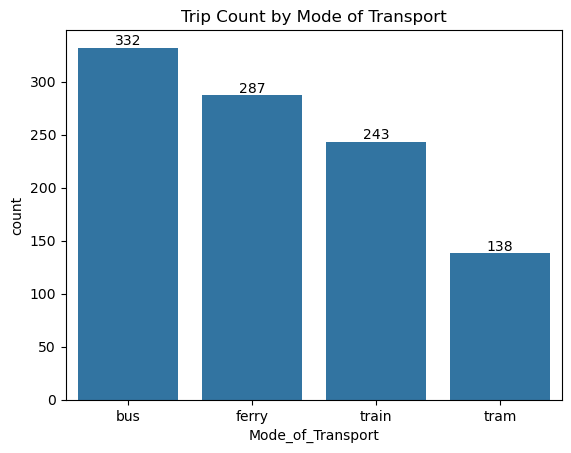

In [42]:
## Lets see Trip count distibution by mode of transportation

ax = sns.countplot(x=df['Mode_of_Transport'], order = df['Mode_of_Transport'].value_counts(ascending=False).index)
values = df['Mode_of_Transport'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=values)
ax.set_title('Trip Count by Mode of Transport')

## Narrate Observation

In [43]:
##Lets see the days customers travel the most 
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Trip_Year',
       'Trip_Month', 'Trip_Month_Number', 'Trip_Quarter'],
      dtype='object')

Text(0.5, 1.0, 'Trip Distribution by Day of the Week')

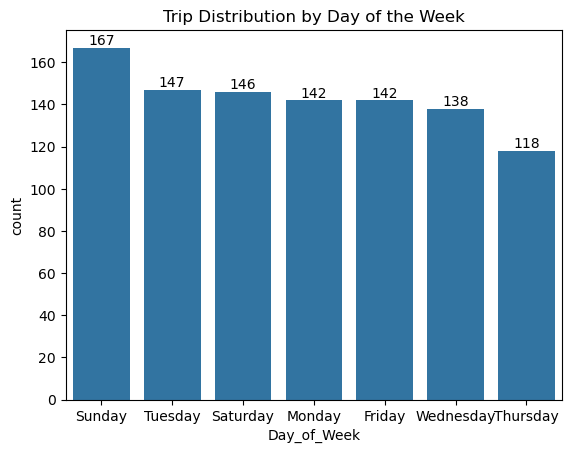

In [46]:
axa = sns.countplot(x = df['Day_of_Week'], order = df['Day_of_Week'].value_counts(ascending=False).index)
values = df['Day_of_Week'].value_counts(ascending=False)
axa.bar_label(container=axa.containers[0], label=values)
axa.set_title('Trip Distribution by Day of the Week')

## Narrate Observation

Text(0.5, 1.0, 'Trip Distribution by Month')

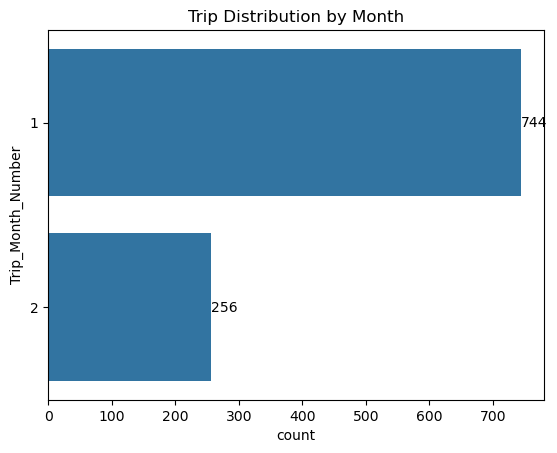

In [53]:
## Lets see the months customers travel the most and least 
axb = sns.countplot(y = df['Trip_Month_Number'], order = df['Trip_Month_Number'].value_counts(ascending=False).index)
values = df['Trip_Month_Number'].value_counts(ascending=False)
axb.bar_label(container=axb.containers[0], label =values)
axb.set_title('Trip Distribution by Month')

## Narrate Observation

In [50]:
## Lets see the travel trend by year 
df['Trip_Month_Number'].unique()

array([1, 2], dtype=int32)

In [51]:
df['Trip_Month'].unique()

array([<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x15b1bb0e0>>],
      dtype=object)

In [52]:
df['Trip_Year'].unique()

array([2024], dtype=int32)

Apparently, Everything hapenned in 2024
## Bivariate Analysis


Lets see Average Fare amount vs day of the week

I can use aggregates for passenger count vs days of the week

I can also explore which transport mode passengers prefer to travel on or the busiest. 

sums for passenger counts  and averages for ticket prices

I can see most popular destinations by doing sum passenger count 

I can see busiest origin stations by sum of passenger count 

I will try binning to morning, afternoon and evening or binning to each hour 24hrs of departure time to see Rush hour peasks and quiet periods. 
I should try to order the days f week as well on th charts and allocate colors to the day on the chart

The company wants to use this data to improve passenger experience and optimise operations so my questions should be around this.

In [54]:
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Trip_Year',
       'Trip_Month', 'Trip_Month_Number', 'Trip_Quarter'],
      dtype='object')

In [62]:
avg_fare = df.groupby('Day_of_Week')['Fare_Amount'].mean().reset_index()
avg_fare
avg_fare.style.format({'Fare_Amount': '{:.2f}'}) # formatting the fare amount to 2 decimal places

,Day_of_Week,Fare_Amount
0,Friday,25.07
1,Monday,26.17
2,Saturday,24.55
3,Sunday,24.72
4,Thursday,28.19
5,Tuesday,24.42
6,Wednesday,25.05


[Text(0, 0, '25.067057004918023'),
 Text(0, 0, '26.171550551469434'),
 Text(0, 0, '24.545677982393798'),
 Text(0, 0, '24.72425939808294'),
 Text(0, 0, '28.190456107413112'),
 Text(0, 0, '24.418599027526255'),
 Text(0, 0, '25.045155719954714')]

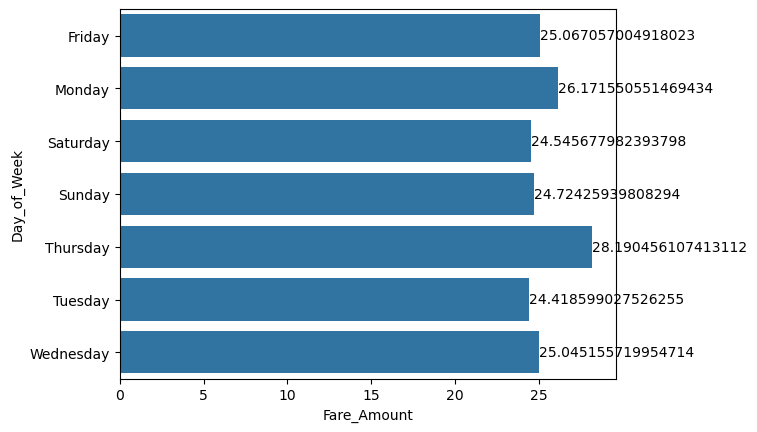

In [71]:
axc = sns.barplot(y='Day_of_Week', data=avg_fare, x='Fare_Amount')
values = avg_fare['Fare_Amount']
axc.bar_label(container=axc.containers[0], labels=values)

## Narrate Observation 

We can see that average fares were pretty same just rising slightly on Thursdays and Monday. 

In [72]:
passenger_sum = df.groupby('Day_of_Week')['Passenger_Count'].sum().reset_index() #group passenger count by day of week they travelled
passenger_sum

,Day_of_Week,Passenger_Count
0,Friday,6603.934444
1,Monday,7225.853333
2,Saturday,7443.934444
3,Sunday,7710.780000
4,Thursday,5875.390000
5,Tuesday,7497.544444
6,Wednesday,6797.007778


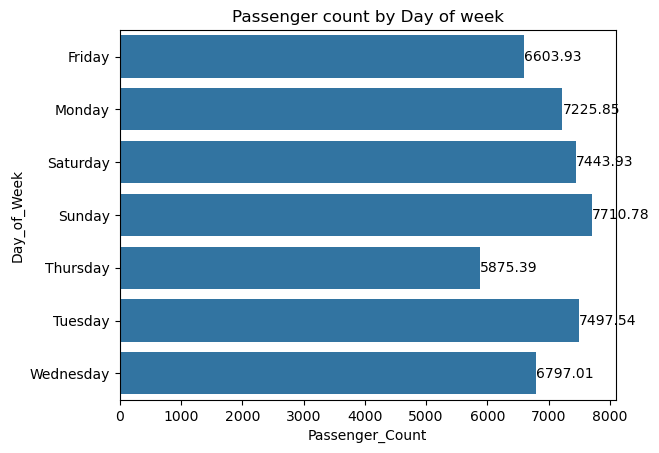

In [86]:
plt.plot(figuresize=(20,15))
axd = sns.barplot(y = 'Day_of_Week', data=passenger_sum, x='Passenger_Count')
values = passenger_sum['Passenger_Count']
axd.bar_label(container=axd.containers[0], label=values)
axd.set_title('Passenger count by Day of week')
plt.show()
## FOrmat this to show whole numbers, probably see how I can change the passenger count column to whole numbers on the original table. 
## It has decimals because I replaced the 100 missing values with the mean values

Narrate Observation

In [87]:
# Lets see the most popular modes of transportation
passenger_sum2 = df.groupby('Mode_of_Transport')['Passenger_Count'].sum().reset_index()
passenger_sum2

,Mode_of_Transport,Passenger_Count
0,bus,16312.324444
1,ferry,14332.861111
2,train,11473.096667
3,tram,7036.162222


[Text(0, 0, '16312.3'),
 Text(0, 0, '14332.9'),
 Text(0, 0, '11473.1'),
 Text(0, 0, '7036.16')]

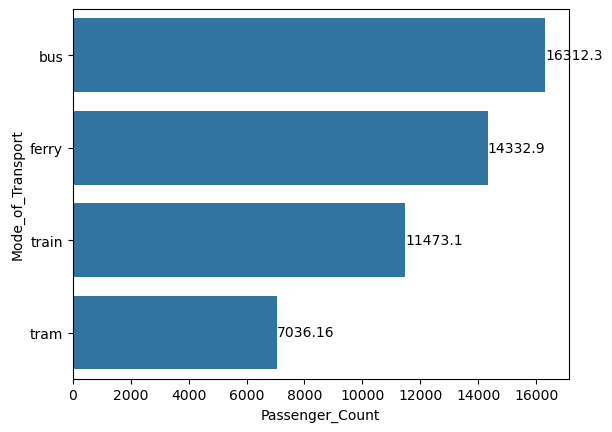

In [88]:
axe = sns.barplot(y = 'Mode_of_Transport', data=passenger_sum2, x='Passenger_Count')
values = passenger_sum2['Passenger_Count']
axe.bar_label(container=axe.containers[0], label=values)

### Narrate Observation 

Bus is the most popular transportation option for passengers with a whooping 16K transported over the year to and fro from their destinations. tram is the least popular with the lowest number of passengers over time 7K 

In [89]:
# Lets see popular destinations and busiest origin stations
df.columns

Index(['Trip_ID', 'Mode_of_Transport', 'Departure_Station', 'Arrival_Station',
       'Departure_Time', 'Passenger_Count', 'Fare_Amount',
       'Trip_Duration_Minutes', 'Trip_Date', 'Day_of_Week', 'Trip_Year',
       'Trip_Month', 'Trip_Month_Number', 'Trip_Quarter'],
      dtype='object')

In [91]:
busy_stations = df.groupby('Departure_Station')['Passenger_Count'].sum().reset_index()
busy_stations

,Departure_Station,Passenger_Count
0,Airport,7576.162222
1,Central,10942.243333
2,Downtown,7824.316667
3,North Station,8287.088889
4,South Point,6695.853333
5,West End,7828.780000


[Text(0, 0, '7576'),
 Text(0, 0, '10942'),
 Text(0, 0, '7824'),
 Text(0, 0, '8287'),
 Text(0, 0, '6696'),
 Text(0, 0, '7829')]

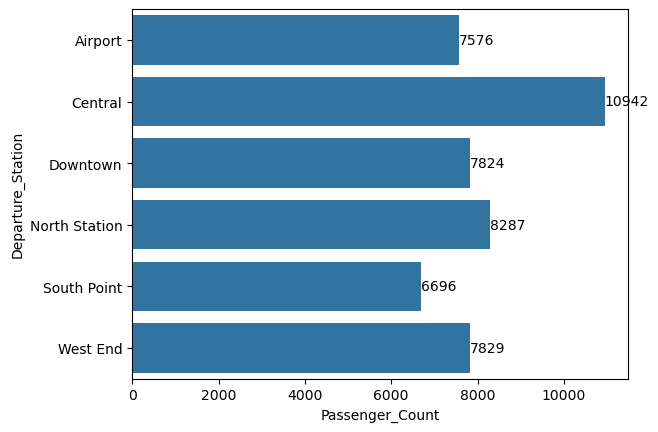

In [96]:
axf = sns.barplot(y = 'Departure_Station', data=busy_stations, x='Passenger_Count')
busy_stations['Passenger_Count'] = busy_stations['Passenger_Count'].round(0).astype(int) # rounding the asenger count to whole numbers
values = busy_stations['Passenger_Count']
axf.bar_label(container=axf.containers[0], labels=values)

# Narrate Observation

With 10K passengers departing Central Station, its evidently the busiest departure station by far with the next busienst station being the North station which has abour 2K less passengers. Airpoet, Downtown and West End stations have averagely same range of passengers departing from there and the South point station as the station with the lowest number of passenger departures.  

RWe should check Trips Count by departure Station and Arrival Stations as well. To see if the trips cater for the amount of passengers expectations

In [97]:
popular_dest = df.groupby('Arrival_Station')['Passenger_Count'].sum().reset_index()
popular_dest

,Arrival_Station,Passenger_Count
0,Airport,10873.478889
1,Central,7442.316667
2,Downtown,8671.471111
3,North Station,6135.235556
4,South Point,8327.316667
5,West End,7704.625556


[Text(0, 0, '10873'),
 Text(0, 0, '7442'),
 Text(0, 0, '8671'),
 Text(0, 0, '6135'),
 Text(0, 0, '8327'),
 Text(0, 0, '7705')]

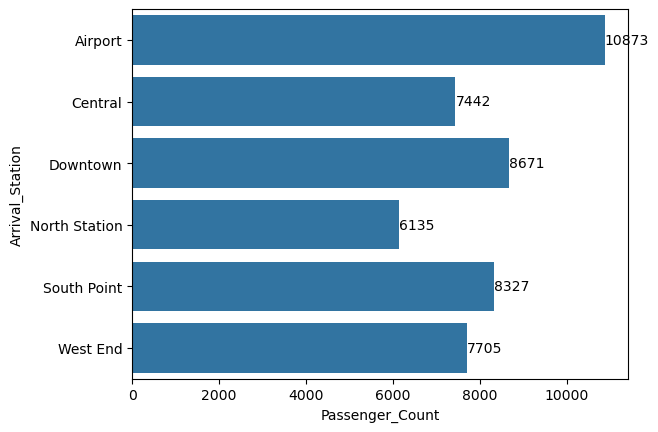

In [98]:
axg = sns.barplot(y = 'Arrival_Station', data=popular_dest, x='Passenger_Count')
popular_dest['Passenger_Count'] = popular_dest['Passenger_Count'].round(0).astype(int) # rounding the pasenger count to whole numbers
values = popular_dest['Passenger_Count']
axg.bar_label(container=axg.containers[0], labels=values)

## narrate Observation
i can order in subplots the mode of transport, popular destinations, passenger count, avg ticket prices and trip count to the popular destination and busiest departure stations